# Story Book Maker — 직접 돌려보기 (노트북 · Runner)

테마(또는 내 동화) → **Story Writer**가 5페이지 글 → **Illustrator**가 페이지별 그림.
과제 공식 테스트는 `adk web`. 이 노트북은 `Runner`로 셀 단위 실행 실습용. (#12.6)

> **1~2** 준비물 → **3~5** 에이전트 조립 → **6** 실행엔진 → **7~8** 입력·실행 → **9~10** 결과.


## 0. 키 로드
**왜:** 그림은 OpenAI로 만들어서 키 필요. 없으면 뒤가 다 에러니 미리 `assert`로 막음.


In [ ]:
import os
from dotenv import load_dotenv

load_dotenv("storybook_maker/.env")
assert os.getenv("OPENAI_API_KEY"), "storybook_maker/.env 에 OPENAI_API_KEY 를 넣으세요"
print("키 로드 OK")


## 1. import + 모델
**왜:** 쓸 도구 불러옴. ADK 기본이 Gemini라 GPT는 `LiteLlm`로 감쌈. (deprecation 경고는 무해 → 숨김)


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from pydantic import BaseModel, Field
from google.adk.agents import Agent, SequentialAgent
from google.adk.models.lite_llm import LiteLlm
from google.adk.tools import ToolContext
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.adk.artifacts import InMemoryArtifactService
from google.genai import types
from openai import OpenAI
import base64

MODEL = LiteLlm(model="openai/gpt-4o-mini")


## 2. 구조화 스키마
**왜:** 두 에이전트가 주고받을 계약서. + **일관성 장치**:
- `art_style` : 전체 화풍을 **한 번** 정의(모든 그림에 주입 → 실사·만화 섞임 방지)
- `character` : 주인공 외형을 **한 번** 고정(모든 페이지에 주입 → 페이지마다 딴 캐릭터 방지)


In [13]:
class Page(BaseModel):
    page_number: int
    text: str = Field(description="동화 문장 (한국어)")
    visual: str = Field(description="이 페이지 장면 묘사 (영어). 주인공은 늘 같은 외형으로.")

class StoryBook(BaseModel):
    theme: str
    art_style: str = Field(description="전체 삽화 화풍 한 줄(영어). 예: soft watercolor children's storybook illustration")
    character: str = Field(description="주인공 외형 고정 묘사(영어): 색·종류·옷·특징. 모든 페이지 동일.")
    pages: list[Page]


## 3. Story Writer 에이전트
**왜:** 동화 담당. `output_schema`로 형태 강제 + `output_key`로 state 저장(공유 출발).
프롬프트에서 **주인공 하나로 끝까지 / 새 사람·무관 동물 금지**를 못 박아 스토리 자체의 일관성을 잡는다.


In [14]:
WRITER_PROMPT = """
너는 어린이 동화 작가 겸 편집자야. 규칙을 반드시 지켜:
- 주인공은 처음부터 끝까지 **딱 한 캐릭터**. 페이지마다 새 주인공/사람을 등장시키지 마.
- 배경 세계도 일관. 갑자기 실사 같은 사람 사진, 무관한 동물 넣지 마.
- art_style: 전체 삽화 화풍 한 줄(영어). 예: "soft watercolor children's storybook illustration".
- character: 주인공 외형 고정 묘사(영어, 색·종류·옷·특징). 모든 페이지 이 모습 그대로.
- 각 페이지 visual(영어): 그 장면. 주인공은 character와 똑같이 묘사.
- 사용자가 완성된 동화를 주면 그 문장 보존(5페이지로 나눔), 테마만 주면 5페이지 창작.
정확히 5페이지. page_number + text(한국어) + visual(영어).
"""

story_writer = Agent(
    name="StoryWriterAgent",
    model=MODEL,
    instruction=WRITER_PROMPT,
    output_schema=StoryBook,
    output_key="story_writer_output",
)


## 4. Illustrator 도구 (그림 만드는 함수)
**왜:** state에서 동화를 읽어(공유 지점) 페이지별 그림 → artifact 저장.
**핵심 수정:** 각 이미지 프롬프트에 `art_style` + `character`를 **매번 앞에 붙여** 화풍·주인공을 강제 고정. 이게 페이지 간 일관성의 진짜 레버.


In [15]:
async def generate_illustrations(tool_context: ToolContext):
    story = tool_context.state.get("story_writer_output")
    if not story:
        return {"status":"error","reason":"story_writer_output 없음"}
    pages = story.get("pages", [])
    art_style = story.get("art_style", "children's storybook illustration")
    character = story.get("character", "")
    existing = await tool_context.list_artifacts()
    client = OpenAI()
    made = []
    for page in pages:
        n, visual = page["page_number"], page["visual"]
        fname = f"page_{n}_image.jpeg"
        if fname in existing:
            continue
        # 화풍 + 주인공을 매 페이지에 강제 주입 → 일관성
        prompt = (f"{art_style}. Main character, always identical: {character}. "
                  f"Scene: {visual}. Keep the exact same art style and character design as every page.")
        resp = client.images.generate(
            model="gpt-image-1", prompt=prompt, n=1,
            moderation="low", output_format="jpeg",
            background="opaque", size="1024x1024", quality="low",
        )
        img = base64.b64decode(resp.data[0].b64_json)
        await tool_context.save_artifact(fname, types.Part.from_bytes(mime_type="image/jpeg", data=img))
        made.append({"page": n, "filename": fname})
    return {"status":"complete", "total_images": len(made), "images": made}


## 5. Illustrator 에이전트 + 파이프라인
**왜:** 도구 쥔 에이전트 + Writer→Illustrator 순서(`SequentialAgent`). Writer가 먼저 state 채워야 Illustrator가 읽음.


In [16]:
illustrator = Agent(
    name="IllustratorAgent",
    model=MODEL,
    instruction="generate_illustrations 도구를 한 번 호출해 각 페이지 삽화를 만들어.",
    tools=[generate_illustrations],
    output_key="illustrator_output",
)

root_agent = SequentialAgent(
    name="StoryBookMaker",
    sub_agents=[story_writer, illustrator],
)


/var/folders/y0/w5dc1fws67d6q8bm4gt7g3ph0000gn/T/ipykernel_30149/3227244215.py:9: DeprecationWarning: SequentialAgent is deprecated and will be removed in future versions. Please use Workflow instead.
  root_agent = SequentialAgent(


## 6. Runner 준비
**왜:** 정의만 한 걸 실제로 굴리는 엔진 + 저장소. Runner=for loop, SessionService=대화/state, ArtifactService=그림파일. 메모리라 커널 끄면 사라짐.


In [17]:
APP, USER = "storybook_maker", "me"
session_service = InMemorySessionService()
artifact_service = InMemoryArtifactService()
runner = Runner(
    agent=root_agent, app_name=APP,
    session_service=session_service, artifact_service=artifact_service,
)


## 7. 입력 — 테마 또는 **내 동화**
**왜:** 뭘 만들지 정하는 유일한 곳. 바꿔 실험은 여기서만.


In [18]:
STORY = "보라색 하늘을 좋아하는 작은 흰 토끼 베니의 모험"
# STORY = """(내 동화 전문 붙여넣기)"""


## 8. 실행 (Writer → Illustrator)
**왜:** 파이프라인 돌림. 어떤 도구 불렸는지 찍음. 그림 5장이라 시간·비용 좀 듦.


In [19]:
session = await session_service.create_session(app_name=APP, user_id=USER)
msg = types.Content(role="user", parts=[types.Part(text=STORY)])

async for ev in runner.run_async(user_id=USER, session_id=session.id, new_message=msg):
    if calls := ev.get_function_calls():
        print("🛠 tool:", [c.name for c in calls])
    if ev.is_final_response():
        print("✅ 파이프라인 완료")
SID = session.id


✅ 파이프라인 완료
🛠 tool: ['generate_illustrations']
✅ 파이프라인 완료


## 9. 결과 — state의 동화 (+ 고정된 화풍·주인공 확인)


In [20]:
s = await session_service.get_session(app_name=APP, user_id=USER, session_id=SID)
story = s.state["story_writer_output"]
print("🎨 art_style:", story["art_style"])
print("🧸 character:", story["character"], "\n")
for p in story["pages"]:
    print(f"[Page {p['page_number']}] {p['text']}")
    print(f"    visual: {p['visual']}\n")


🎨 art_style: soft watercolor children's storybook illustration
🧸 character: Benny: a small, fluffy white rabbit with big round eyes, wearing a tiny blue scarf around his neck. 

[Page 1] 작은 흰 토끼 베니는 보라색 하늘을 사랑했습니다. 매일 저녁, 베니는 언덕 위에 올라가 하늘을 바라보며 그 색이 얼마나 아름다운지를 생각했어요.
    visual: Benny the little fluffy white rabbit standing on a green hill, gazing up at the beautiful purple sky filled with clouds.

[Page 2] 어느 날, 베니는 보라색 하늘의 비밀을 찾고 싶어졌습니다. 그래서 그는 모험을 떠나기로 결심했어요. '보라색 하늘을 가까이에서 보고 싶어!'
    visual: Benny looking determined and excited, ready for adventure with a small backpack on his back, standing at the edge of his little burrow.

[Page 3] 베니는 숲을 지나고, 작은 강을 건넜습니다. 강가에 있는 친구들이 그를 보고 응원해 주었죠. '네가 보라색 하늘을 찾을 수 있을 거야, 베니!'
    visual: Benny hopping across a small wooden bridge over a sparkling blue stream, while a few forest animals cheer him on from the riverbank.

[Page 4] 드디어, 베니는 높은 산에 도착했습니다. 그곳은 보라색 하늘을 직접 만날 수 있는 곳이었어요. 하늘의 색이 더욱 짙어보였어요!
    visual: Benny standing triumphantly on to

## 10. 삽화 — Artifact 이미지 보기
⚠️ ArtifactService 시그니처는 ADK 버전 따라 다를 수 있음. 에러 나면 알려줘.


page_1_image.jpeg


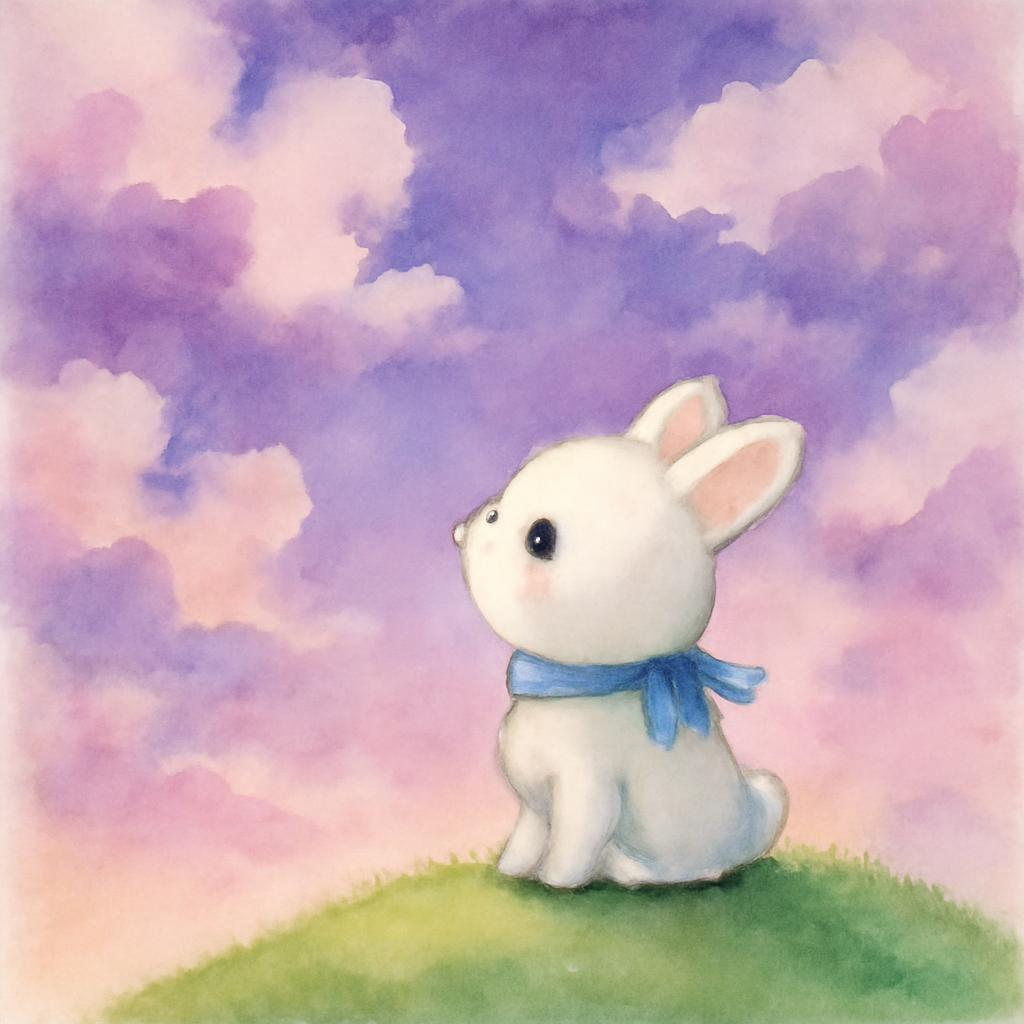

page_2_image.jpeg


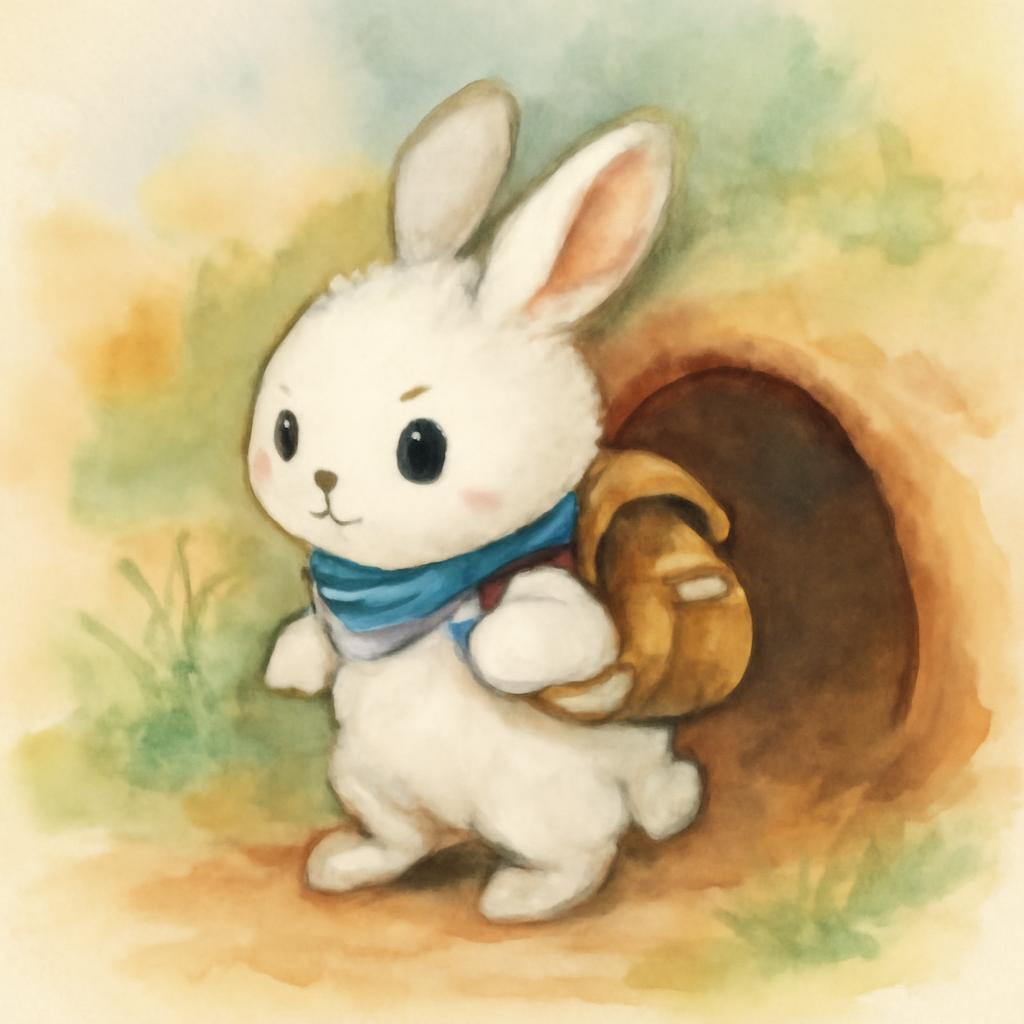

page_3_image.jpeg


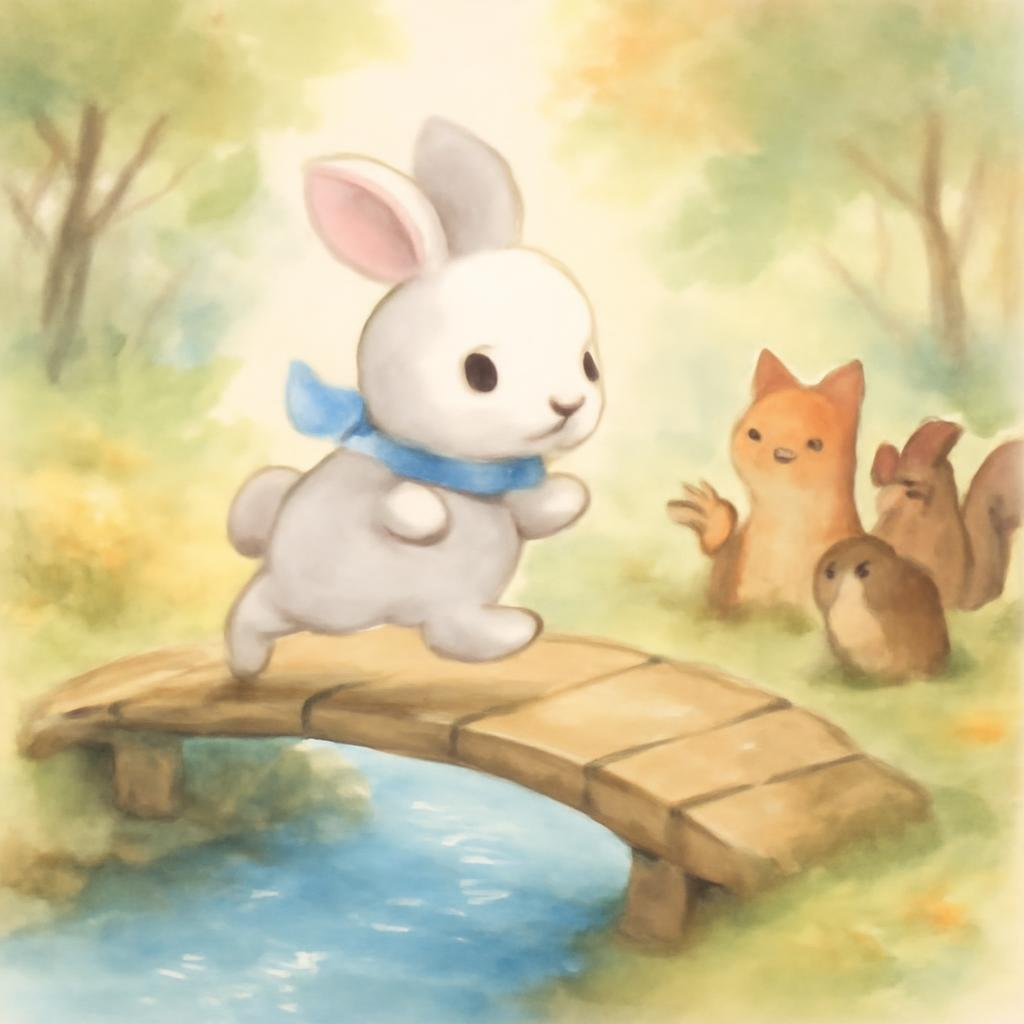

page_4_image.jpeg


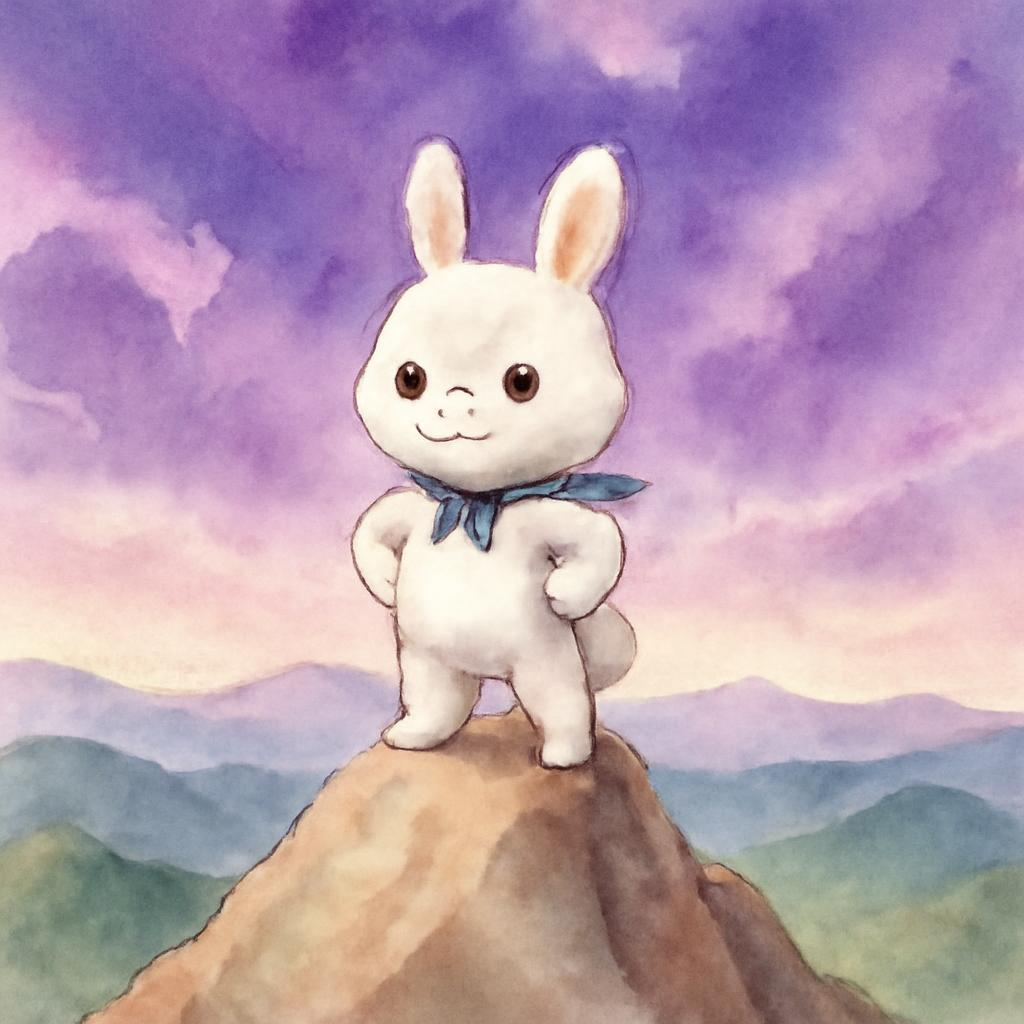

page_5_image.jpeg


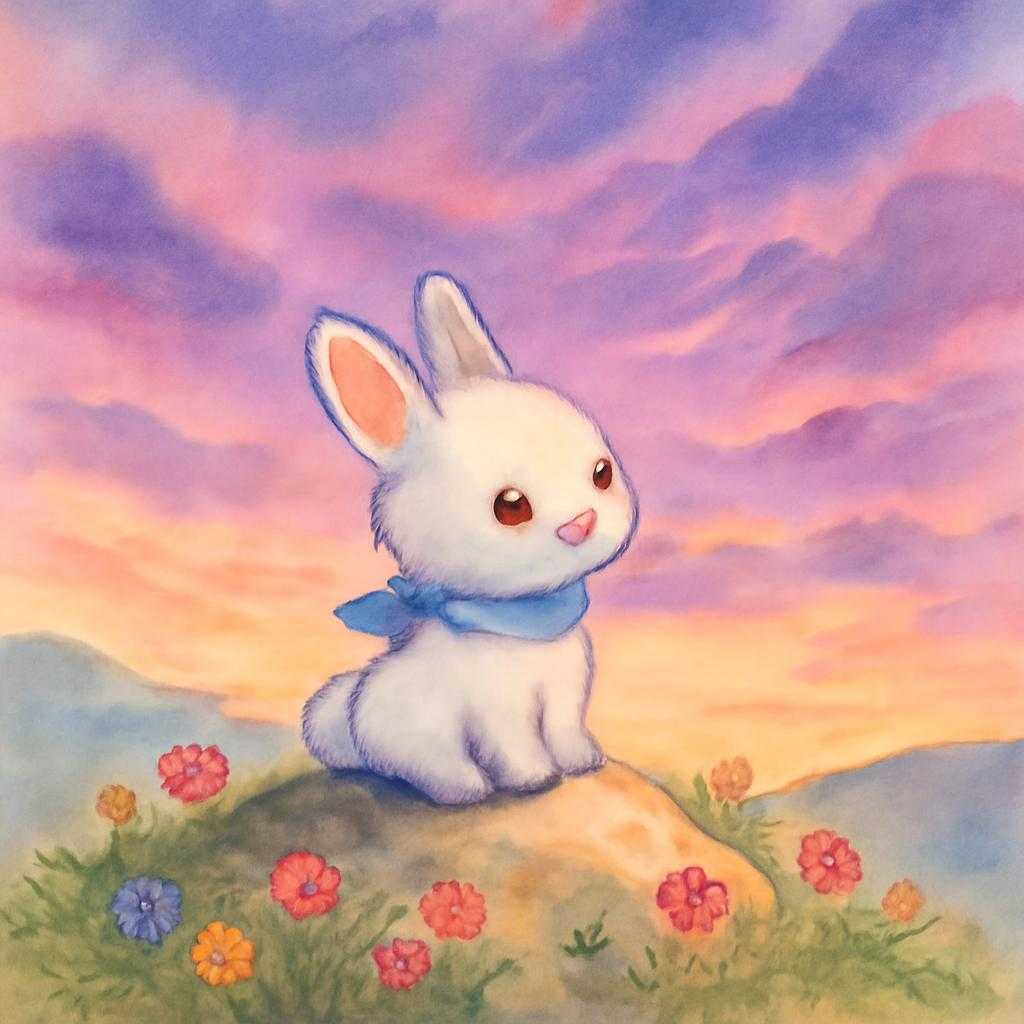

In [21]:
from IPython.display import Image, display

keys = await artifact_service.list_artifact_keys(app_name=APP, user_id=USER, session_id=SID)
for k in sorted(keys):
    part = await artifact_service.load_artifact(app_name=APP, user_id=USER, session_id=SID, filename=k)
    print(k)
    display(Image(data=part.inline_data.data))


## 11. 내 동화로 바꿔보기
**왜:** 7번 STORY만 바꿔 8~10 재실행. Writer가 내 문장 보존 + 주인공/화풍 고정.

과제 제출 테스트는 `adk web` (패키지)로도 한 번.
